<a href="https://colab.research.google.com/github/contactyuvrajchand-droid/machine_learning_lab/blob/main/Week_7_Naive_Bayes_Spam_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 0 — Install required packages


In [ ]:
!pip install pyspark nltk scikit-learn matplotlib -q


## Step 1 — Import libraries and start Spark


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    IndexToString,
    RegexTokenizer,
    StopWordsRemover,
    CountVectorizer,
    IDF,
    Binarizer
)
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

plt.style.use("ggplot")

spark = SparkSession.builder \
    .appName("Enron_Spam_Naive_Bayes_Assessment") \
    .getOrCreate()

print("Spark session created successfully.")
print("Spark version:", spark.version)


Spark session created successfully.
Spark version: 4.0.3


## Step 2 — Upload the Enron Email Dataset

Run this cell and upload the provided labelled Enron CSV file. If the file is already stored in Google Drive, replace dataset_path with its Drive path after mounting Drive.


In [ ]:
from google.colab import files

print("Upload the labelled Enron Email Dataset CSV file.")
uploaded = files.upload()

dataset_path = "/content/" + list(uploaded.keys())[0]
print("Dataset path:", dataset_path)


Upload the labelled Enron Email Dataset CSV file.


Saving emails.csv to emails.csv
Dataset path: /content/emails.csv


## Step 3 — Load the dataset into a Spark DataFrame

The multiLine, quote, and escape options allow Spark to read real emails that contain commas and line breaks inside quoted message fields.


In [ ]:
raw_df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("multiLine", "true")
    .option("quote", '"')
    .option("escape", '"')
    .csv(dataset_path)
)

print("Original columns:", raw_df.columns)
print("Original row count:", raw_df.count())
raw_df.show(5, truncate=100)


Original columns: ['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flow'

## Step 4 — Detect the label and email columns

Different copies of the labelled Enron dataset use slightly different column names. This cell identifies the relevant columns without requiring manual renaming.


In [ ]:
def normalise_column_name(name):
    return re.sub(r"[^a-z0-9]", "", name.lower())

normalised_columns = {
    normalise_column_name(column): column
    for column in raw_df.columns
}


def find_column(candidates, required=True):
    # First try an exact normalised match
    for candidate in candidates:
        key = normalise_column_name(candidate)
        if key in normalised_columns:
            return normalised_columns[key]

    # Then try a partial match
    for candidate in candidates:
        key = normalise_column_name(candidate)
        for normalised_name, original_name in normalised_columns.items():
            if key in normalised_name or normalised_name in key:
                return original_name

    if required:
        raise ValueError(
            f"Could not identify a required column. Available columns: {raw_df.columns}"
        )
    return None


label_column = find_column([
    "label", "spam/ham", "spam_ham", "spamham",
    "class", "category", "target", "spam"
])

message_column = find_column([
    "message", "email message", "email", "text",
    "content", "body", "email body"
])

subject_column = find_column([
    "subject", "email subject", "title"
], required=False)

print("Detected label column  :", label_column)
print("Detected message column:", message_column)
print("Detected subject column:", subject_column)


Detected label column  : class
Detected message column: message
Detected subject column: subject


## Step 5 — Clean and standardise the dataset

The cleaned DataFrame contains:

- **label**: standardised as ham or spam
- **message**: the subject and email body combined into one text field
- **message_length**: number of characters in the email


In [ ]:
# Convert common text and numeric label formats into ham/spam
raw_label = F.lower(F.trim(F.col(label_column).cast("string")))

standard_label = (
    F.when(
        raw_label.isin("spam", "1", "1.0", "true", "yes"),
        F.lit("spam")
    )
    .when(
        raw_label.isin(
            "ham", "0", "0.0", "false", "no",
            "not spam", "non-spam", "nonspam"
        ),
        F.lit("ham")
    )
)

# Combine Subject and Message when a subject column is available
message_body = F.coalesce(
    F.col(message_column).cast("string"),
    F.lit("")
)

if subject_column is not None:
    email_text = F.concat_ws(
        " ",
        F.coalesce(F.col(subject_column).cast("string"), F.lit("")),
        message_body
    )
else:
    email_text = message_body

# Clean null values, blank messages and duplicate emails
df = (
    raw_df
    .select(
        standard_label.alias("label"),
        F.trim(email_text).alias("message")
    )
    .filter(F.col("label").isin("ham", "spam"))
    .filter(F.col("message").isNotNull())
    .filter(F.length(F.col("message")) > 0)
    .dropDuplicates(["label", "message"])
    .withColumn("message_length", F.length(F.col("message")))
    .cache()
)

print("Rows after cleaning:", df.count())
df.show(5, truncate=100)


Rows after cleaning: 69
+-----+-------+--------------+
|label|message|message_length|
+-----+-------+--------------+
|  ham|    8 9|             3|
|  ham|    1 9|             3|
|  ham|    0 1|             3|
|  ham|    7 0|             3|
|  ham|    3 6|             3|
+-----+-------+--------------+
only showing top 5 rows


## Step 6 — Inspect class balance and message lengths

Spam datasets are often imbalanced. For this reason, the final comparison prioritises the spam-class F1-score instead of relying only on accuracy.


Class distribution:
+-----+-----+
|label|count|
+-----+-----+
|  ham|   59|
| spam|   10|
+-----+-----+

Average message length by class:
+-----+------+--------------+--------------+--------------+
|label|emails|average_length|minimum_length|maximum_length|
+-----+------+--------------+--------------+--------------+
|  ham|    59|          3.19|             3|             5|
| spam|    10|           3.0|             3|             3|
+-----+------+--------------+--------------+--------------+



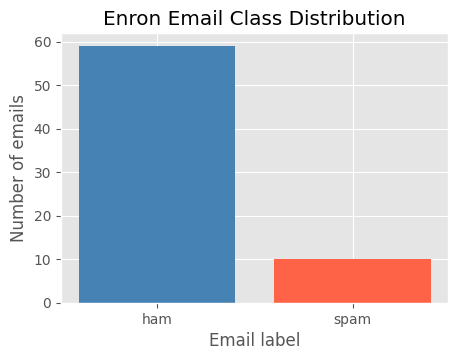

In [ ]:
print("Class distribution:")
class_distribution = (
    df.groupBy("label")
    .count()
    .orderBy(F.desc("count"))
)
class_distribution.show()

print("Average message length by class:")
df.groupBy("label").agg(
    F.count("*").alias("emails"),
    F.round(F.avg("message_length"), 2).alias("average_length"),
    F.min("message_length").alias("minimum_length"),
    F.max("message_length").alias("maximum_length")
).show()

# Plot the class distribution
balance_pd = class_distribution.toPandas()

plt.figure(figsize=(5, 3.5))
plt.bar(balance_pd["label"], balance_pd["count"], color=["steelblue", "tomato"])
plt.title("Enron Email Class Distribution")
plt.xlabel("Email label")
plt.ylabel("Number of emails")
plt.show()


## Step 7 — Split the data

The same 80/20 split is used for all three algorithms so that their metrics are directly comparable.


In [ ]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

train_df = train_df.cache()
test_df = test_df.cache()

print("Training records:", train_df.count())
print("Testing records :", test_df.count())

print("Training class distribution:")
train_df.groupBy("label").count().orderBy("label").show()

print("Testing class distribution:")
test_df.groupBy("label").count().orderBy("label").show()


Training records: 55
Testing records : 14
Training class distribution:
+-----+-----+
|label|count|
+-----+-----+
|  ham|   48|
| spam|    7|
+-----+-----+

Testing class distribution:
+-----+-----+
|label|count|
+-----+-----+
|  ham|   11|
| spam|    3|
+-----+-----+



## Step 8 — Define the complete Spark ML pipelines

Each model pipeline performs the full workflow independently:

| Stage | Purpose |
|---|---|
| StringIndexer | Converts ham and spam into numeric labels |
| RegexTokenizer | Splits an email into lowercase word tokens |
| StopWordsRemover | Removes common English words |
| CountVectorizer | Creates term-frequency vectors |
| IDF | Converts term frequency into TF-IDF features |
| NaiveBayes | Trains the selected Naïve Bayes version |

Bernoulli Naïve Bayes requires binary word-presence features. Its pipeline therefore applies a Binarizer to the TF-IDF vector before classification.


In [ ]:
def build_naive_bayes_pipeline(model_type):
    # Alphabetical ordering guarantees: ham = 0 and spam = 1
    label_indexer = StringIndexer(
        inputCol="label",
        outputCol="label_num",
        stringOrderType="alphabetAsc",
        handleInvalid="skip"
    )

    tokenizer = RegexTokenizer(
        inputCol="message",
        outputCol="tokens",
        pattern=r"\W+", # Changed pattern to split by non-alphanumeric characters
        toLowercase=True,
        minTokenLength=1 # Changed minTokenLength to allow single-digit tokens
    )

    # Removed StopWordsRemover as messages are not natural language

    count_vectorizer = CountVectorizer(
        inputCol="tokens", # Changed inputCol from filtered_tokens to tokens
        outputCol="tf_features",
        vocabSize=10000,
        minDF=1.0 # Changed minDF to 1.0 to ensure vocabulary is not empty for small datasets
    )

    idf = IDF(
        inputCol="tf_features",
        outputCol="features"
    )

    common_stages = [
        label_indexer,
        tokenizer,
        count_vectorizer,
        idf
    ]

    if model_type == "bernoulli":
        # Bernoulli NB accepts only 0/1 feature values
        binarizer = Binarizer(
            inputCol="features",
            outputCol="bernoulli_features",
            threshold=0.0
        )

        classifier = NaiveBayes(
            featuresCol="bernoulli_features",
            labelCol="label_num",
            modelType="bernoulli",
            smoothing=1.0
        )

        stages = common_stages + [binarizer, classifier]

    elif model_type == "gaussian":
        classifier = NaiveBayes(
            featuresCol="features",
            labelCol="label_num",
            modelType="gaussian"
        )

        stages = common_stages + [classifier]

    else:
        classifier = NaiveBayes(
            featuresCol="features",
            labelCol="label_num",
            modelType="multinomial",
            smoothing=1.0
        )

        stages = common_stages + [classifier]

    return Pipeline(stages=stages)

pipelines = {
    "Multinomial NB": build_naive_bayes_pipeline("multinomial"),
    "Bernoulli NB": build_naive_bayes_pipeline("bernoulli"),
    "Gaussian NB": build_naive_bayes_pipeline("gaussian")
}

print("Created the three complete Spark ML pipelines.")

Created the three complete Spark ML pipelines.


## Step 9 — Train all three Naïve Bayes models


In [ ]:
trained_models = {}
predictions = {}
label_mappings = {}

for model_name, pipeline in pipelines.items():
    print(f"Training {model_name}...")

    fitted_model = pipeline.fit(train_df)
    model_predictions = fitted_model.transform(test_df)

    # The first fitted stage is the StringIndexerModel
    label_model = fitted_model.stages[0]
    labels = label_model.labels

    # Convert numeric predictions back to ham/spam text labels
    prediction_converter = IndexToString(
        inputCol="prediction",
        outputCol="predicted_label",
        labels=labels
    )
    model_predictions = prediction_converter.transform(model_predictions)

    trained_models[model_name] = fitted_model
    predictions[model_name] = model_predictions.cache()
    label_mappings[model_name] = labels

    # Materialise and report the prediction count
    print(f"{model_name} predictions:", predictions[model_name].count())

print("All models trained successfully.")


Training Multinomial NB...
Multinomial NB predictions: 14
Training Bernoulli NB...
Bernoulli NB predictions: 14
Training Gaussian NB...
Gaussian NB predictions: 14
All models trained successfully.


## Step 10 — Inspect predictions and label mappings


In [ ]:
for model_name, model_predictions in predictions.items():
    labels = label_mappings[model_name]

    print(f"\n{model_name}")
    print("Label mapping:", {float(i): label for i, label in enumerate(labels)})

    model_predictions.select(
        "label",
        "label_num",
        "predicted_label",
        "prediction",
        "probability",
        "message"
    ).show(5, truncate=100)



Multinomial NB
Label mapping: {0.0: 'ham', 1.0: 'spam'}
+-----+---------+---------------+----------+----------------------------------------+-------+
|label|label_num|predicted_label|prediction|                             probability|message|
+-----+---------+---------------+----------+----------------------------------------+-------+
|  ham|      0.0|            ham|       0.0| [0.905148644865006,0.09485135513499394]|    7 0|
|  ham|      0.0|            ham|       0.0|[0.7313100800477993,0.26868991995220076]|   10 0|
|  ham|      0.0|            ham|       0.0|[0.9587872602257297,0.04121273977427025]|    0 4|
|  ham|      0.0|            ham|       0.0|[0.9362315912730755,0.06376840872692441]|    8 1|
|  ham|      0.0|            ham|       0.0|   [0.5448189158378899,0.45518108416211]|   12 0|
+-----+---------+---------------+----------+----------------------------------------+-------+
only showing top 5 rows

Bernoulli NB
Label mapping: {0.0: 'ham', 1.0: 'spam'}
+-----+---------+-

## Step 11 — Evaluate accuracy, spam precision, spam recall and spam F1-score

For spam detection:

- **Accuracy** measures all correct predictions.
- **Spam precision** measures how many predicted spam emails are actually spam.
- **Spam recall** measures how many real spam emails were detected.
- **Spam F1-score** balances spam precision and recall.

Class-specific spam metrics are more informative than weighted metrics when ham and spam are imbalanced.


In [ ]:
def evaluate_predictions(model_predictions, labels):
    spam_index = float(labels.index("spam"))

    accuracy = MulticlassClassificationEvaluator(
        labelCol="label_num",
        predictionCol="prediction",
        metricName="accuracy"
    ).evaluate(model_predictions)

    precision = MulticlassClassificationEvaluator(
        labelCol="label_num",
        predictionCol="prediction",
        metricName="precisionByLabel",
        metricLabel=spam_index
    ).evaluate(model_predictions)

    recall = MulticlassClassificationEvaluator(
        labelCol="label_num",
        predictionCol="prediction",
        metricName="recallByLabel",
        metricLabel=spam_index
    ).evaluate(model_predictions)

    f1_score = MulticlassClassificationEvaluator(
        labelCol="label_num",
        predictionCol="prediction",
        metricName="fMeasureByLabel",
        metricLabel=spam_index,
        beta=1.0
    ).evaluate(model_predictions)

    return {
        "Accuracy": float(accuracy),
        "Spam Precision": float(precision),
        "Spam Recall": float(recall),
        "Spam F1-score": float(f1_score)
    }


results = []

for model_name, model_predictions in predictions.items():
    model_metrics = evaluate_predictions(
        model_predictions,
        label_mappings[model_name]
    )

    results.append({
        "Model": model_name,
        **model_metrics
    })

results_pd = pd.DataFrame(results).sort_values(
    "Spam F1-score",
    ascending=False
).reset_index(drop=True)

print("Naïve Bayes comparison:")
display(results_pd.style.format({
    "Accuracy": "{:.4f}",
    "Spam Precision": "{:.4f}",
    "Spam Recall": "{:.4f}",
    "Spam F1-score": "{:.4f}"
}))


Naïve Bayes comparison:


,Model,Accuracy,Spam Precision,Spam Recall,Spam F1-score
0,Multinomial NB,0.7857,0.5000,0.3333,0.4000
1,Gaussian NB,0.5714,0.2857,0.6667,0.4000
2,Bernoulli NB,0.7857,0.0000,0.0000,0.0000


## Step 12 — Visualise the metric comparison


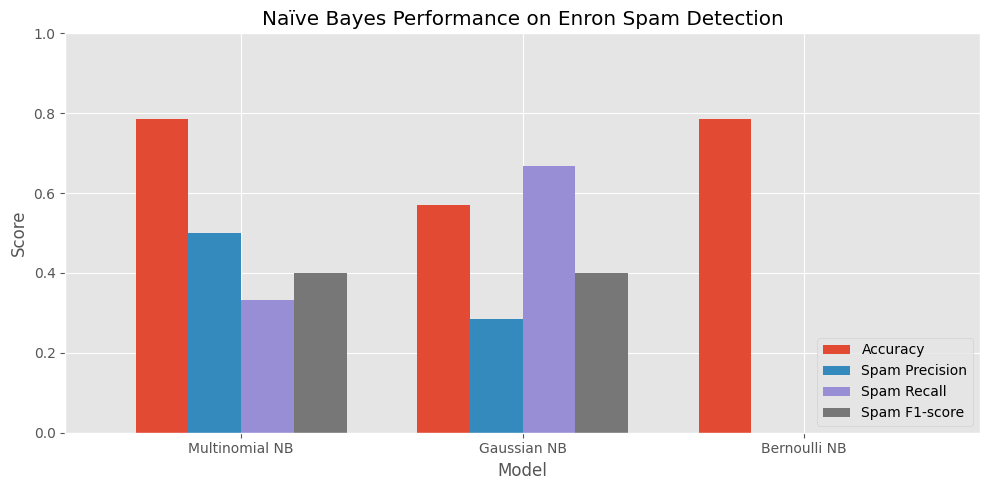

In [ ]:
metric_columns = [
    "Accuracy",
    "Spam Precision",
    "Spam Recall",
    "Spam F1-score"
]

results_pd.set_index("Model")[metric_columns].plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1),
    width=0.75
)

plt.title("Naïve Bayes Performance on Enron Spam Detection")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Step 13 — Confusion matrices

The confusion matrices show correct and incorrect ham/spam predictions for each algorithm.


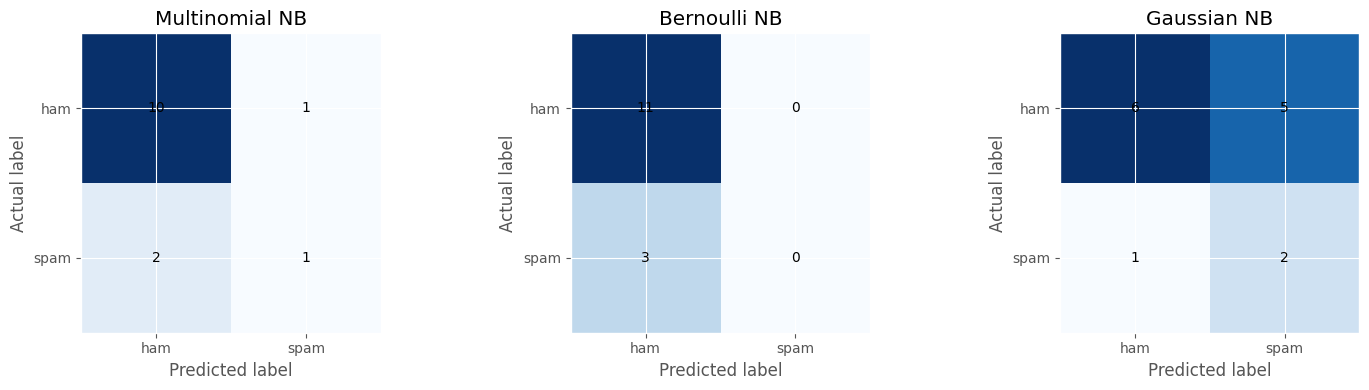

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for axis, (model_name, model_predictions) in zip(axes, predictions.items()):
    confusion_pd = model_predictions.select(
        "label_num",
        "prediction"
    ).toPandas()

    matrix = confusion_matrix(
        confusion_pd["label_num"],
        confusion_pd["prediction"],
        labels=[0.0, 1.0]
    )

    axis.imshow(matrix, cmap="Blues")

    for (row, column), value in np.ndenumerate(matrix):
        axis.text(
            column,
            row,
            int(value),
            ha="center",
            va="center",
            color="black"
        )

    axis.set_xticks([0, 1], ["ham", "spam"])
    axis.set_yticks([0, 1], ["ham", "spam"])
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("Actual label")
    axis.set_title(model_name)

plt.tight_layout()
plt.show()


## Step 14 — Determine and analyse the best model

The best model is selected using the **spam F1-score**, because spam detection must balance false spam warnings (precision) with missed spam emails (recall).


In [ ]:
best_result = results_pd.iloc[0]
best_model_name = best_result["Model"]

print("Best model:", best_model_name)
print(f"Accuracy       : {best_result['Accuracy']:.4f}")
print(f"Spam precision: {best_result['Spam Precision']:.4f}")
print(f"Spam recall   : {best_result['Spam Recall']:.4f}")
print(f"Spam F1-score : {best_result['Spam F1-score']:.4f}")

if best_model_name == "Multinomial NB":
    explanation = (
        "Multinomial Naïve Bayes performed best because its probability model "
        "is well suited to non-negative word-frequency and TF-IDF text features."
    )
elif best_model_name == "Bernoulli NB":
    explanation = (
        "Bernoulli Naïve Bayes performed best because the presence or absence "
        "of particular words was more useful than their TF-IDF magnitude."
    )
else:
    explanation = (
        "Gaussian Naïve Bayes performed best on this split because the continuous "
        "TF-IDF values provided the strongest class separation, although its "
        "Gaussian assumption is generally less natural for sparse text features."
    )

print("\nAnalysis:")
print(explanation)
print(
    "Accuracy alone was not used to choose the winner because a model can obtain "
    "high accuracy by favouring the majority ham class. Spam F1-score provides a "
    "better balance between detecting spam and avoiding false alarms."
)


Best model: Multinomial NB
Accuracy       : 0.7857
Spam precision: 0.5000
Spam recall   : 0.3333
Spam F1-score : 0.4000

Analysis:
Multinomial Naïve Bayes performed best because its probability model is well suited to non-negative word-frequency and TF-IDF text features.
Accuracy alone was not used to choose the winner because a model can obtain high accuracy by favouring the majority ham class. Spam F1-score provides a better balance between detecting spam and avoiding false alarms.


## Step 15 — Inspect misclassified emails from the best model

Reviewing errors helps explain why some legitimate and unwanted emails are difficult to separate.


In [ ]:
best_predictions = predictions[best_model_name]

misclassified = best_predictions.filter(
    F.col("label") != F.col("predicted_label")
)

print("Number of misclassified test emails:", misclassified.count())

misclassified.select(
    "label",
    "predicted_label",
    "probability",
    "message"
).show(15, truncate=150)


Number of misclassified test emails: 3
+-----+---------------+----------------------------------------+-------+
|label|predicted_label|                             probability|message|
+-----+---------------+----------------------------------------+-------+
| spam|            ham|[0.9587872602257297,0.04121273977427025]|    4 0|
|  ham|           spam| [0.4842134163602534,0.5157865836397466]|    1 0|
| spam|            ham|[0.8928417648960993,0.10715823510390068]|    2 3|
+-----+---------------+----------------------------------------+-------+



## Conclusion

This assessment implemented three complete PySpark Naïve Bayes pipelines on the labelled Enron Email Dataset. All models used label indexing, tokenisation, stop-word removal, CountVectorizer and IDF feature extraction. Multinomial and Gaussian Naïve Bayes used the TF-IDF values directly, while Bernoulli Naïve Bayes used binary word-presence features derived from TF-IDF.

The final model should be selected using the results produced above. In an imbalanced spam dataset, the spam F1-score is normally the most appropriate single comparison metric because it balances precision and recall.


## Optional — Stop the Spark session


In [ ]:
# spark.stop()
